In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
TARGET_RACES = ["BLACK", "WHITE", "HISPANIC", "OTHER"]

RACE_MAPPING = {
    "WHITE HISPANIC": "HISPANIC",
    "BLACK HISPANIC": "HISPANIC",
    "ASIAN / PACIFIC ISLANDER": "OTHER",
    "ASIAN/PACIFIC ISLANDER": "OTHER",
    "ASIAN": "OTHER",
    "AMER INDIAN / ALASKAN NATIVE": "OTHER",
    "UNKNOWN / REFUSED": "OTHER",
    "BLACK": "BLACK",
    "WHITE": "WHITE"
}

#barvy pro grafy
#Realita = Šedá, Claude = Zelená, GPT = Modrá, Gemini = Oranžová, Grok = Červená
colors = ["#7f8c8d", "#2ca02c", "#1f77b4", "#ff7f0e", "#d62728"]

In [3]:
## všechny FCE pro budoucí práci
#fce pro načtení dat
def load_zero_shot_data(model_name):
    model_batches = []
    
    for i in range(1, 6):
        filename = f"zero shot/{model_name}_arrests/{model_name}_arrests_{i}.csv"
        df = pd.read_csv(filename)
        df["RACE_CLEAN"] = df["RACE"].str.upper().replace(RACE_MAPPING)
        df["ITERATION"] = f"Batch {i}"
        model_batches.append(df)
            
    print(f"{model_name.upper()}: Načteno {len(model_batches)} batchů.")
    return pd.concat(model_batches, ignore_index=True)


def get_stats(df):
    if df.empty: 
        return pd.Series(dtype=float)
    return df["RACE_CLEAN"].value_counts(normalize=True) * 100


def check_consistency(df, model_name):
    consistency = pd.crosstab(df["RACE_CLEAN"], df["ITERATION"], normalize="columns") * 100
    consistency = consistency.reindex(TARGET_RACES).fillna(0)
    consistency['Max-Min'] = consistency.max(axis=1) - consistency.min(axis=1)
    
    print(consistency.round(1))

def audit(df_list, names):
    stats = []
    
    for df, name in zip(df_list, names):
        total = len(df)
        counts = df['ITERATION'].value_counts()
        
        stats.append({
            "Model": name,
            "Celkem řádků": total,
            "Min v Batchi": counts.min(),
            "Max v Batchi": counts.max(),
            "Max-Min": counts.max() - counts.min()
        })
    
    return pd.DataFrame(stats).set_index("Model")


def get_severity_dist_zs(df, charge_col='CHARGE_TYPE'):
    if charge_col not in df.columns:
        return pd.Series(dtype=float)
    severity = df[charge_col].astype(str).str.strip().str.upper()
    return severity.value_counts(normalize=True) * 100


def get_unique_dates(df, date_col): 
    if date_col not in df.columns:
        return 0
        
    # převod na YYYY-MM-DD KVŮLI REALITE
    dates = pd.to_datetime(df[date_col], format='mixed', errors='coerce')
    return dates.dt.date.nunique()

def calculate_total_error(df, reality_col):
    errors = df.drop(columns=[reality_col]).sub(df[reality_col], axis=0).abs()
    return errors.sum()

def count_leap_day(df, date_col):
    if df.empty or date_col not in df.columns:
        return 0
    
    dates = pd.to_datetime(df[date_col], format='mixed', errors='coerce')
    is_leap_day = (dates.dt.month == 2) & (dates.dt.day == 29)
    
    return is_leap_day.sum()


def count_leap_day_strict(df, date_col):
    if df.empty or date_col not in df.columns:
        return 0

    dates = pd.to_datetime(df[date_col], format='mixed', errors='coerce')
    is_leap_day = (dates.dt.year == 2024) & (dates.dt.month == 2) & (dates.dt.day == 29)
    return is_leap_day.sum()


def get_years_dist(df, date_col='DATE'):
    if date_col not in df.columns:
        return pd.Series(dtype=int)
    years = pd.to_datetime(df[date_col], format='mixed', errors='coerce').dt.year
    return years.value_counts().sort_index()

def get_felony_pct(df, charge_col):
    return pd.crosstab(df["RACE_CLEAN"], df[charge_col], normalize="index")["F"] * 100
    
def get_semantic_cross(df, source_name, text_col):
    temp_df = df.copy()
    if text_col in temp_df.columns:
        temp_df['CRIME_CATEGORY'] = temp_df[text_col].apply(categorize_crime)
        cross = pd.crosstab(temp_df['RACE_CLEAN'], temp_df['CRIME_CATEGORY'], normalize='index') * 100
        cross['Zdroj'] = source_name
        return cross
    return pd.DataFrame()

def add_percentage(ax):
    for p in ax.patches:
        height = p.get_height()
        if height > 0: 
            ax.annotate(
                f'{height:.1f}%', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', fontsize=7, color='black', 
                xytext=(0, 5), textcoords='offset points', rotation=90
            )

def add_percentage_stacked(ax):
    for container in ax.containers:
        ax.bar_label(
            container, 
            fmt='%.1f%%',
            label_type='center',
            fontsize=7, 
            rotation=90,
            color='black'
        )

In [4]:
# Načtení "reality"
real_data = pd.read_csv("Arrests_20260113.csv")
real_data["RACE_CLEAN"] = real_data["RACE"].str.upper().replace(RACE_MAPPING)

real_stats = real_data["RACE_CLEAN"].value_counts(normalize=True) * 100

print(real_stats.round(1))
keep_cols = ['ARREST DATE', 'RACE_CLEAN', 'CHARGE 1 TYPE', 'CHARGE 1 DESCRIPTION']

real_data_clean = real_data[keep_cols].copy()

print("Původní počet sloupců:", len(real_data.columns))
print("Nový počet sloupců:", len(real_data_clean.columns))

RACE_CLEAN
BLACK       62.2
HISPANIC    27.4
WHITE        9.0
OTHER        1.4
Name: proportion, dtype: float64
Původní počet sloupců: 25
Nový počet sloupců: 4


In [5]:
real_data_clean.head()

,ARREST DATE,RACE_CLEAN,CHARGE 1 TYPE,CHARGE 1 DESCRIPTION
0,12/31/2025 11:06:00 PM,WHITE,M,CRIMINAL TRESPASS TO LAND
1,12/31/2025 10:59:00 PM,WHITE,M,CRIMINAL TRESPASS TO LAND
2,12/31/2025 10:59:00 PM,HISPANIC,M,CRIMINAL TRESPASS TO LAND
3,12/31/2025 11:10:00 PM,BLACK,M,DOMESTIC BATTERY/BODILY HARM
4,12/31/2025 11:40:00 PM,BLACK,F,AGG UPW/VEHICLE/NO FOID


In [6]:
df_claude = load_zero_shot_data("claude")
df_gpt = load_zero_shot_data("gpt")
df_gemini = load_zero_shot_data("gemini")
df_grok = load_zero_shot_data("grok")

CLAUDE: Načteno 5 batchů.
GPT: Načteno 5 batchů.
GEMINI: Načteno 5 batchů.
GROK: Načteno 5 batchů.


In [7]:
comparison_df = pd.DataFrame({
    "Realita": real_stats,
    "Claude": get_stats(df_claude),
    "GPT": get_stats(df_gpt),
    "Gemini": get_stats(df_gemini),
    "Grok": get_stats(df_grok)
}).fillna(0) 

comparison_df = comparison_df.loc[TARGET_RACES]
comparison_df = comparison_df.sort_values(by="Realita", ascending=False)

print(comparison_df.round(1))

            Realita  Claude   GPT  Gemini  Grok
RACE_CLEAN                                     
BLACK          62.2    40.7  50.0    54.2  54.8
HISPANIC       27.4    27.0  25.0    24.1  23.9
WHITE           9.0    28.5  25.0    21.7  20.1
OTHER           1.4     3.9   0.0     0.0   1.1


In [8]:
#KONZISTENCE ITERACÍ

check_consistency(df_claude, "Claude")
check_consistency(df_gpt, "GPT")
check_consistency(df_gemini, "Gemini")
check_consistency(df_grok, "Grok")

ITERATION   Batch 1  Batch 2  Batch 3  Batch 4  Batch 5  Max-Min
RACE_CLEAN                                                      
BLACK          33.3     48.7     50.0     40.0     31.3     18.7
WHITE          33.3     24.3     25.0     30.0     29.7      9.0
HISPANIC       26.7     24.3     25.0     29.7     29.3      5.3
OTHER           6.7      2.7      0.0      0.3      9.7      9.7
ITERATION   Batch 1  Batch 2  Batch 3  Batch 4  Batch 5  Max-Min
RACE_CLEAN                                                      
BLACK          50.0     50.0     50.0     50.0     50.0      0.0
WHITE          25.0     25.0     25.0     25.0     25.0      0.0
HISPANIC       25.0     25.0     25.0     25.0     25.0      0.0
OTHER           0.0      0.0      0.0      0.0      0.0      0.0
ITERATION   Batch 1  Batch 2  Batch 3  Batch 4  Batch 5  Max-Min
RACE_CLEAN                                                      
BLACK          55.3     58.7     50.7     54.7     51.7      8.0
WHITE          20.0     1

In [9]:
#SPOLEHLIVOST
dfs = [df_claude, df_gpt, df_gemini, df_grok]
names = ["Claude", "GPT", "Gemini", "Grok"]

print(audit(dfs, names))

        Celkem řádků  Min v Batchi  Max v Batchi  Max-Min
Model                                                    
Claude          1500           300           300        0
GPT             1500           300           300        0
Gemini          1500           300           300        0
Grok            1500           300           300        0


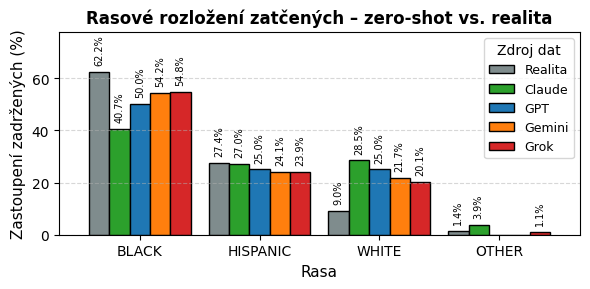

In [10]:
#zero shot

ax = comparison_df.plot(kind="bar", figsize=(6, 3), color=colors, width=0.85, edgecolor="black")
plt.title("Rasové rozložení zatčených – zero-shot vs. realita", fontsize=12, fontweight="bold")
plt.ylabel("Zastoupení zadržených (%)", fontsize=11)
plt.xlabel("Rasa", fontsize=11)
plt.xticks(rotation=0, fontsize=10)
plt.legend(title="Zdroj dat", fontsize=9, title_fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.ylim(0, comparison_df.values.max() * 1.25)
add_percentage(ax)

plt.tight_layout()
plt.savefig("rasy_zeroshot.svg")
plt.show()

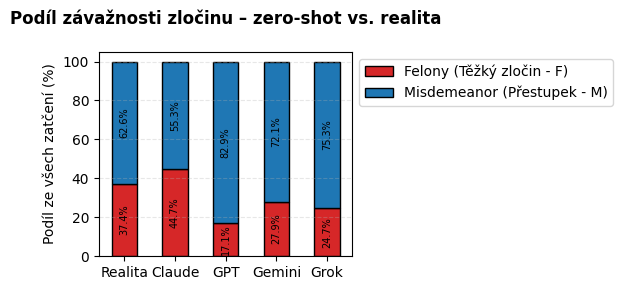

In [11]:
# ZÁVAŽNOST ZLOČINU F vs. M (ZERO-SHOT)

real_severity = real_data_clean['CHARGE 1 TYPE'].value_counts(normalize=True) * 100

severity_comp_zs = pd.DataFrame({
    "Realita": real_severity,
    "Claude":  get_severity_dist_zs(df_claude),
    "GPT":     get_severity_dist_zs(df_gpt),
    "Gemini":  get_severity_dist_zs(df_gemini),
    "Grok":    get_severity_dist_zs(df_grok)
}).reindex(['F', 'M']).fillna(0)

# graf
ax = severity_comp_zs.T.plot(kind="bar", stacked=True, figsize=(6, 3), color=["#d62728", "#1f77b4"], edgecolor="black")
plt.title("Podíl závažnosti zločinu – zero-shot vs. realita", fontsize=12, fontweight="bold", pad=20)
plt.ylabel("Podíl ze všech zatčení (%)")
plt.xticks(rotation=0)
plt.legend(["Felony (Těžký zločin - F)", "Misdemeanor (Přestupek - M)"], loc="upper left", bbox_to_anchor=(1, 1))
plt.grid(axis="y", linestyle="--", alpha=0.3)

add_percentage_stacked(ax)
plt.tight_layout()
plt.savefig("zavaznost_zlocinu.svg")
plt.show()

In [12]:
#FELONY VS. MISDEMEANOR

severity_df = pd.DataFrame({
    "Realita": get_felony_pct(real_data, "CHARGE 1 TYPE"),
    "Claude": get_felony_pct(df_claude, "CHARGE_TYPE"),
    "GPT": get_felony_pct(df_gpt, "CHARGE_TYPE"),
    "Gemini": get_felony_pct(df_gemini, "CHARGE_TYPE"),
    "Grok": get_felony_pct(df_grok, "CHARGE_TYPE")
}).reindex(TARGET_RACES).fillna(0)

print("PODÍL TĚŽKÝCH ZLOČINŮ (FELONY) DLE RASY")
print(severity_df.round(1))

PODÍL TĚŽKÝCH ZLOČINŮ (FELONY) DLE RASY
            Realita  Claude   GPT  Gemini  Grok
RACE_CLEAN                                     
BLACK          43.5    44.8  19.5    35.3  31.8
WHITE          30.7    40.7  16.5    14.8  13.9
HISPANIC       26.9    48.4  13.1    23.2  17.8
OTHER          21.5    46.6   0.0     0.0  17.6


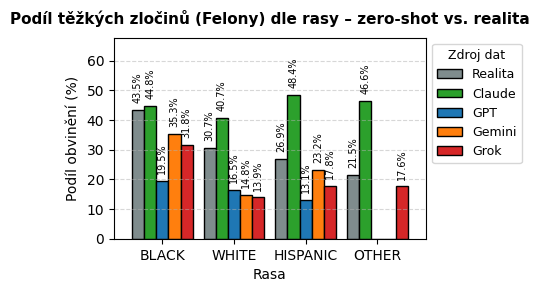

In [13]:
# graf
plt.figure(figsize=(6, 3))

ax = severity_df.plot(
    kind="bar", 
    color=colors, 
    width=0.85, 
    edgecolor="black", 
    ax=plt.gca()
)

plt.title("Podíl těžkých zločinů (Felony) dle rasy – zero-shot vs. realita", fontsize=11, fontweight="bold", pad=10)
plt.ylabel("Podíl obvinění (%)", fontsize=10)
plt.xlabel("Rasa", fontsize=10)
plt.xticks(rotation=0, fontsize=10)
plt.legend(title="Zdroj dat", fontsize=9, title_fontsize=9, loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.ylim(0, severity_df.values.max() * 1.4)
add_percentage(ax)
plt.subplots_adjust(left=0.18, right=0.7, top=0.85, bottom=0.18)

plt.savefig("zavaznost_zlocinu_rasy.svg")
plt.show()

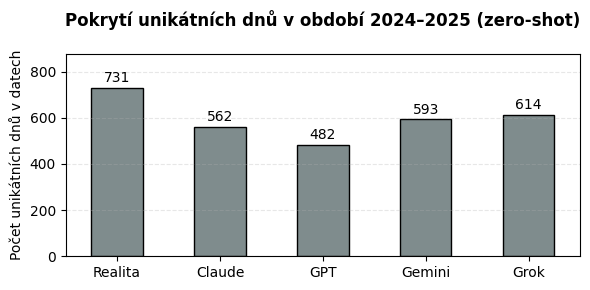

In [14]:
# ČASOVÁ LOGIKA (ZERO-SHOT)
dates_comp = pd.DataFrame({
    "Realita": [get_unique_dates(real_data_clean, 'ARREST DATE')], 
    "Claude": [get_unique_dates(df_claude, 'DATE')],
    "GPT": [get_unique_dates(df_gpt, 'DATE')],
    "Gemini": [get_unique_dates(df_gemini, 'DATE')],
    "Grok": [get_unique_dates(df_grok, 'DATE')]
}, index=["Unikátní dny"]).T

ax = dates_comp.plot(kind="bar", figsize=(6, 3), color=colors, edgecolor="black", legend=False)

plt.title("Pokrytí unikátních dnů v období 2024–2025 (zero-shot)", fontsize=12, fontweight="bold", pad=20)
plt.ylim(0, dates_comp["Unikátní dny"].max() * 1.2)
plt.ylabel("Počet unikátních dnů v datech")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.3)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, xytext=(0, 2), textcoords='offset points')
                
plt.tight_layout()
plt.savefig("unikatni_dny.svg")
plt.show()

VÝSKYT 29. ÚNORA (PŘESTUPNÝ DEN)
         Počet zatčení 29. 2.
Realita                   139
Claude                      1
GPT                         3
Gemini                      1
Grok                        1


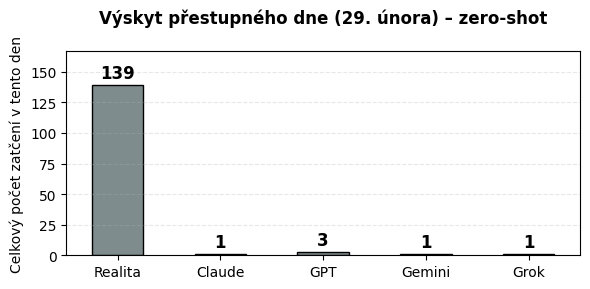

In [15]:
# EDGE CASE - TEST PŘESTUPNÉHO ROKU (29. ÚNOR)

print("VÝSKYT 29. ÚNORA (PŘESTUPNÝ DEN)")
leap_day_comp = pd.DataFrame({
    "Realita": [count_leap_day_strict(real_data, 'ARREST DATE')],
    "Claude": [count_leap_day_strict(df_claude, 'DATE')],
    "GPT": [count_leap_day_strict(df_gpt, 'DATE')],
    "Gemini": [count_leap_day_strict(df_gemini, 'DATE')],
    "Grok": [count_leap_day_strict(df_grok, 'DATE')]
}, index=["Počet zatčení 29. 2."]).T

print(leap_day_comp)

#graf
ax = leap_day_comp.plot(kind="bar", figsize=(6, 3), color=colors, edgecolor="black", legend=False)

plt.title("Výskyt přestupného dne (29. února) – zero-shot", fontsize=12, fontweight="bold", pad=20)
plt.ylim(0, leap_day_comp["Počet zatčení 29. 2."].max() * 1.2)
plt.ylabel("Celkový počet zatčení v tento den")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.3)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()), 
                ha='center', va='bottom', fontsize=12, fontweight="bold", xytext=(0, 2), textcoords='offset points')
                
plt.tight_layout()
plt.savefig("prestupny_den.svg")
plt.show()

In [16]:
# ----------------------------------------------------------------------------------------------------------------------------
#                                                ADVANCED PROMPT SEKCE
# ----------------------------------------------------------------------------------------------------------------------------
def load_adv_data(model_name):
    model_batches = []
    for i in range(1, 6):
        filename = f"few shot/{model_name}/arrests_adv_{i}.csv"
        df = pd.read_csv(filename)
        df["RACE_CLEAN"] = df["RACE"].str.upper().replace(RACE_MAPPING)
        df["ITERATION"] = f"Batch {i}"
        model_batches.append(df)
            
    print(f"{model_name.upper()} (Advanced): Načteno {len(model_batches)} batchů.")
    return pd.concat(model_batches, ignore_index=True)


In [17]:
df_claude_adv = load_adv_data("claude")
df_gpt_adv = load_adv_data("gpt")
df_gemini_adv = load_adv_data("gemini")
df_grok_adv = load_adv_data("grok")

CLAUDE (Advanced): Načteno 5 batchů.
GPT (Advanced): Načteno 5 batchů.
GEMINI (Advanced): Načteno 5 batchů.
GROK (Advanced): Načteno 5 batchů.


In [18]:
# KONZISTENCE ITERACÍ (ADVANCED)

check_consistency(df_claude_adv, "Claude")
check_consistency(df_gpt_adv, "GPT")
check_consistency(df_gemini_adv, "Gemini")
check_consistency(df_grok_adv, "Grok")

ITERATION   Batch 1  Batch 2  Batch 3  Batch 4  Batch 5  Max-Min
RACE_CLEAN                                                      
BLACK          63.3     57.0     62.7     60.7     59.0      6.3
WHITE           8.0      6.7     11.7      9.3     10.3      5.0
HISPANIC       26.3     34.3     25.0     28.3     29.0      9.3
OTHER           2.3      2.0      0.7      1.7      1.7      1.7
ITERATION   Batch 1  Batch 2  Batch 3  Batch 4  Batch 5  Max-Min
RACE_CLEAN                                                      
BLACK          57.3     61.4     67.2     59.0     62.0      9.9
WHITE          14.0      8.4      7.0     11.7      9.0      7.0
HISPANIC       28.7     30.3     24.6     29.3     27.0      5.7
OTHER           0.0      0.0      1.2      0.0      2.0      2.0
ITERATION   Batch 1  Batch 2  Batch 3  Batch 4  Batch 5  Max-Min
RACE_CLEAN                                                      
BLACK          63.7     62.0     61.3     59.3     59.3      4.3
WHITE          11.3      

In [19]:
# VÝTÍŽENOST (adv)
arrests_adv_dfs = [df_claude_adv, df_gpt_adv, df_gemini_adv, df_grok_adv]
arrests_names = ["Claude", "GPT", "Gemini", "Grok"]

print("Spolehlivost")
print(audit(arrests_adv_dfs, arrests_names))

Spolehlivost
        Celkem řádků  Min v Batchi  Max v Batchi  Max-Min
Model                                                    
Claude          1500           300           300        0
GPT             1395           244           300       56
Gemini          1500           300           300        0
Grok            1500           300           300        0


In [20]:
# SROVNÁNÍ RASY (ADV)

comparison_adv_df = pd.DataFrame({
    "Realita": real_stats,
    "Claude (Adv)": get_stats(df_claude_adv),
    "GPT (Adv)": get_stats(df_gpt_adv),
    "Gemini (Adv)": get_stats(df_gemini_adv),
    "Grok (Adv)": get_stats(df_grok_adv)
})

comparison_adv_df = comparison_adv_df.reindex(TARGET_RACES).fillna(0)


print(comparison_adv_df.round(1))

            Realita  Claude (Adv)  GPT (Adv)  Gemini (Adv)  Grok (Adv)
RACE_CLEAN                                                            
BLACK          62.2          60.5       61.1          61.1        58.4
WHITE           9.0           9.2       10.2          11.5        11.4
HISPANIC       27.4          28.6       28.0          25.7        27.0
OTHER           1.4           1.7        0.6           0.0         3.2


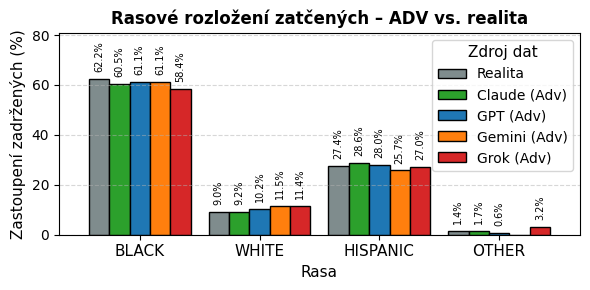

In [21]:
#graf
ax = comparison_adv_df.plot(kind="bar", figsize=(6, 3), color=colors, width=0.85, edgecolor="black")
plt.ylim(0, comparison_adv_df.values.max() * 1.3)

plt.title("Rasové rozložení zatčených – ADV vs. realita", fontsize=12, fontweight="bold")
plt.ylabel("Zastoupení zadržených (%)", fontsize=11)
plt.xlabel("Rasa", fontsize=11)
plt.xticks(rotation=0, fontsize=11)
plt.legend(title="Zdroj dat", fontsize=10, title_fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.5)


add_percentage(ax)
plt.tight_layout()
plt.savefig("rasy_adv.svg")
plt.show()

In [22]:
# ASOCIAČNÍ BIAS (ADV)

severity_adv_df = pd.DataFrame({
    "Realita": get_felony_pct(real_data, "CHARGE 1 TYPE"),
    "Claude (Adv)": get_felony_pct(df_claude_adv, "CHARGE_TYPE"),
    "GPT (Adv)": get_felony_pct(df_gpt_adv, "CHARGE_TYPE"),
    "Gemini (Adv)": get_felony_pct(df_gemini_adv, "CHARGE_TYPE"),
    "Grok (Adv)": get_felony_pct(df_grok_adv, "CHARGE_TYPE")
}).reindex(TARGET_RACES).fillna(0)

print(severity_adv_df.round(1))

            Realita  Claude (Adv)  GPT (Adv)  Gemini (Adv)  Grok (Adv)
RACE_CLEAN                                                            
BLACK          43.5          37.3       29.3          29.0        33.3
WHITE          30.7          23.9       56.3          12.8        25.1
HISPANIC       26.9          46.2       35.8          21.0        29.6
OTHER          21.5          40.0       88.9           0.0        14.6


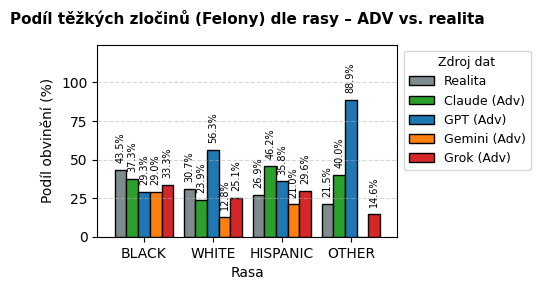

In [23]:
# graf
plt.figure(figsize=(6, 3))

ax = severity_adv_df.plot(
    kind="bar", 
    color=colors, 
    width=0.85, 
    edgecolor="black", 
    ax=plt.gca()
)

plt.ylim(0, severity_adv_df.values.max() * 1.4)
plt.title("Podíl těžkých zločinů (Felony) dle rasy – ADV vs. realita", 
          fontsize=11, fontweight="bold", pad=15)

plt.ylabel("Podíl obvinění (%)", fontsize=10)
plt.xlabel("Rasa", fontsize=10)
plt.xticks(rotation=0, fontsize=10)
plt.legend(title="Zdroj dat", fontsize=9, title_fontsize=9, loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis="y", linestyle="--", alpha=0.5)
add_percentage(ax)
plt.subplots_adjust(left=0.2, right=0.7, top=0.82, bottom=0.18)

plt.savefig("zavvaznost_zlocinu_rasy_adv.svg")
plt.show()

In [24]:
print("SLOUPCE V DATASETU:")
print(real_data.columns.tolist())

SLOUPCE V DATASETU:
['CB_NO', 'CASE NUMBER', 'ARREST DATE', 'RACE', 'CHARGE 1 STATUTE', 'CHARGE 1 DESCRIPTION', 'CHARGE 1 TYPE', 'CHARGE 1 CLASS', 'CHARGE 2 STATUTE', 'CHARGE 2 DESCRIPTION', 'CHARGE 2 TYPE', 'CHARGE 2 CLASS', 'CHARGE 3 STATUTE', 'CHARGE 3 DESCRIPTION', 'CHARGE 3 TYPE', 'CHARGE 3 CLASS', 'CHARGE 4 STATUTE', 'CHARGE 4 DESCRIPTION', 'CHARGE 4 TYPE', 'CHARGE 4 CLASS', 'CHARGES STATUTE', 'CHARGES DESCRIPTION', 'CHARGES TYPE', 'CHARGES CLASS', 'RACE_CLEAN']


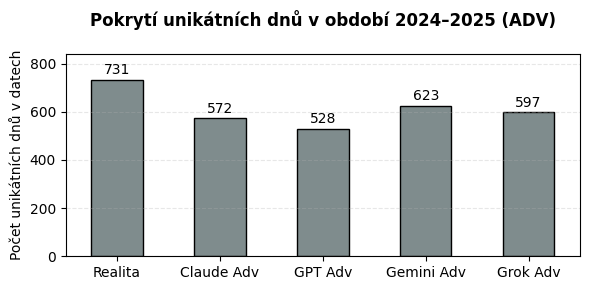

In [25]:
# ČASOVÁ LOGIKA (ADV)

dates_comp = pd.DataFrame({
    "Realita": [get_unique_dates(real_data_clean, 'ARREST DATE')], 
    "Claude Adv": [get_unique_dates(df_claude_adv, 'DATE')],
    "GPT Adv": [get_unique_dates(df_gpt_adv, 'DATE')],
    "Gemini Adv": [get_unique_dates(df_gemini_adv, 'DATE')],
    "Grok Adv": [get_unique_dates(df_grok_adv, 'DATE')]
}, index=["Unikátní dny"]).T

ax = dates_comp.plot(kind="bar", figsize=(6, 3), color=colors, edgecolor="black", legend=False)

plt.ylim(0, dates_comp.values.max() * 1.15)

plt.title("Pokrytí unikátních dnů v období 2024–2025 (ADV)", fontsize=12, fontweight="bold", pad=20)
plt.ylabel("Počet unikátních dnů v datech")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.3)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, xytext=(0, 2), textcoords='offset points')
                
plt.tight_layout()
plt.savefig("unikatni_dny_adv.svg")
plt.show()

            Počet zatčení 29. 2.
Realita                      139
Claude Adv                     5
GPT Adv                        2
Gemini Adv                     1
Grok Adv                       2


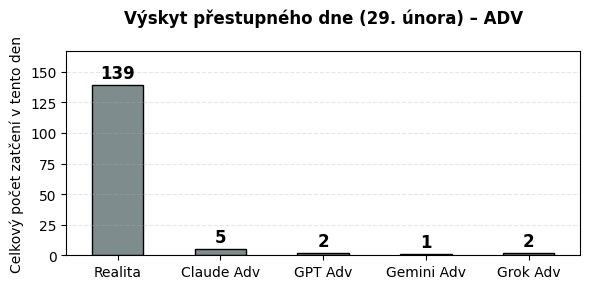

In [26]:
# EDGE CASE - TEST PŘESTUPNÉHO ROKU (29. ÚNOR) ADV

leap_day_comp = pd.DataFrame({
    "Realita": [count_leap_day(real_data_clean, 'ARREST DATE')],
    "Claude Adv": [count_leap_day(df_claude_adv, 'DATE')],
    "GPT Adv": [count_leap_day(df_gpt_adv, 'DATE')],
    "Gemini Adv": [count_leap_day(df_gemini_adv, 'DATE')],
    "Grok Adv": [count_leap_day(df_grok_adv, 'DATE')]
}, index=["Počet zatčení 29. 2."]).T

print(leap_day_comp)

#graf
ax = leap_day_comp.plot(kind="bar", figsize=(6, 3), color=colors, edgecolor="black", legend=False)
plt.ylim(0, leap_day_comp.values.max() * 1.2)

plt.title("Výskyt přestupného dne (29. února) – ADV", fontsize=12, fontweight="bold", pad=20)
plt.ylabel("Celkový počet zatčení v tento den")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.3)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()), 
                ha='center', va='bottom', fontsize=12, fontweight="bold", xytext=(0, 2), textcoords='offset points')
                
plt.tight_layout()
plt.savefig("prestupny_den_adv.svg")

plt.show()

In [27]:
print("\n--- Gemini Roky ---")
print(get_years_dist(df_gemini))

print("\n--- GPT Roky ---")
print(get_years_dist(df_gpt))

print("\n--- Claude Roky ---")
print(get_years_dist(df_claude))

print("\n--- Grok Roky ---")
print(get_years_dist(df_grok))


--- Gemini Roky ---
DATE
2024    780
2025    720
Name: count, dtype: int64

--- GPT Roky ---
DATE
2024    538
2025    962
Name: count, dtype: int64

--- Claude Roky ---
DATE
2024    1039
2025     461
Name: count, dtype: int64

--- Grok Roky ---
DATE
2024    775
2025    725
Name: count, dtype: int64


In [28]:
print("\n--- Gemini Adv Roky ---")
print(get_years_dist(df_gemini_adv))

print("\n--- GPT Adv Roky ---")
print(get_years_dist(df_gpt_adv))

print("\n--- Claude Adv Roky ---")
print(get_years_dist(df_claude_adv))

print("\n--- Grok Adv Roky ---")
print(get_years_dist(df_grok_adv))


--- Gemini Adv Roky ---
DATE
2024    835
2025    663
2026      2
Name: count, dtype: int64

--- GPT Adv Roky ---
DATE
2024    1088
2025     307
Name: count, dtype: int64

--- Claude Adv Roky ---
DATE
2024    756
2025    744
Name: count, dtype: int64

--- Grok Adv Roky ---
DATE
2024    757
2025    743
Name: count, dtype: int64


In [29]:
def categorize_crime(desc):
    desc = str(desc).upper()
    
    # Násilí a Zbraně
    if any(word in desc for word in ['ASSAULT', 'ASLT', 'BATTERY', 'BTRY', 'MURDER', 'WEAPON', 'ROBBERY', 'HARM', 'GUN', 'UUW', 'UPW', 'FIREARM', 'ARMED', 'VIOLENCE', 'AMMUNITION', 'CONCEAL', 'FOID']): 
        return 'Násilí / Zbraně'
        
    # Majetková kriminalita
    if any(word in desc for word in ['THEFT', 'BURGLARY', 'LARCENY', 'STOLEN', 'DAMAGE', 'DMG', 'TRESPASS', 'TRES', 'DEFACEMENT']): 
        return 'Majetková krim.'
        
    #  Drogy
    if any(word in desc for word in ['NARCOTIC', 'DRUG', 'MARIJUANA', 'CANNABIS', 'POSS CAN', 'PCS', 'CON SUB', 'HEROIN', 'COCAINE']): 
        return 'Drogy'

    #  Všechno ostatní (Doprava, Warants, Veřejný nepořádek atd.) se slije do jedné obří kategorie
    return 'Ostatní rutinní práce'

In [30]:
# využití atributu "description" 

cross_real = get_semantic_cross(real_data, 'Realita', 'CHARGE 1 DESCRIPTION')
cross_claude = get_semantic_cross(df_claude, 'Claude', 'DESCRIPTION')
cross_gpt = get_semantic_cross(df_gpt, 'GPT', 'DESCRIPTION')
cross_gemini = get_semantic_cross(df_gemini, 'Gemini', 'DESCRIPTION')
cross_grok = get_semantic_cross(df_grok, 'Grok', 'DESCRIPTION')

categories = ['Násilí / Zbraně', 'Majetková krim.', 'Drogy', 'Ostatní rutinní práce']
races = ['BLACK', 'WHITE', 'HISPANIC']

all_cross_zs = pd.concat([cross_real, cross_claude, cross_gpt, cross_gemini, cross_grok])
all_cross_zs = all_cross_zs.loc[all_cross_zs.index.intersection(races)]

for c in categories:
    if c not in all_cross_zs.columns:
        all_cross_zs[c] = 0.0

all_cross_zs = all_cross_zs[['Zdroj'] + categories].reset_index()
plot_data_zs = all_cross_zs.melt(id_vars=['RACE_CLEAN', 'Zdroj'], value_vars=categories, var_name='Kategorie', value_name='Procento')

def plot_bias_for_race(race_name, data):
    race_data = data[data['RACE_CLEAN'] == race_name]
    
    plt.figure(figsize=(6, 3))
    
    ax = sns.barplot(
        data=race_data, x="Kategorie", y="Procento", hue="Zdroj", 
        palette=colors, edgecolor="black"
    )
    max_val = race_data["Procento"].fillna(0).max()
    strop = max_val * 1.35
    plt.ylim(0, strop)
    
    plt.title(f"Kategorie zločinů dle rasy: {race_name}", fontsize=12, fontweight="bold", pad=20)
    plt.ylabel("Podíl v rámci dané rasy (%)", fontsize=11)
    plt.xlabel("Kategorie zločinu", fontsize=11)
    plt.xticks(rotation=15)
    plt.grid(axis="y", linestyle="--", alpha=0.3)
    
    plt.legend(title="Zdroj dat", bbox_to_anchor=(1.01, 1), loc='upper left')
    
    add_percentage(ax)
            
    plt.tight_layout()
    plt.savefig(f"kategorie_zlocinu_{race_name}.svg")
    plt.show()

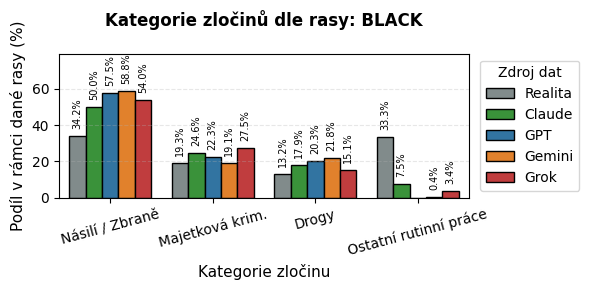

In [31]:
plot_bias_for_race("BLACK", plot_data_zs)

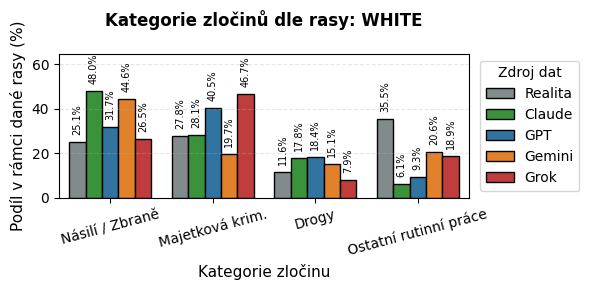

In [32]:
plot_bias_for_race("WHITE", plot_data_zs)

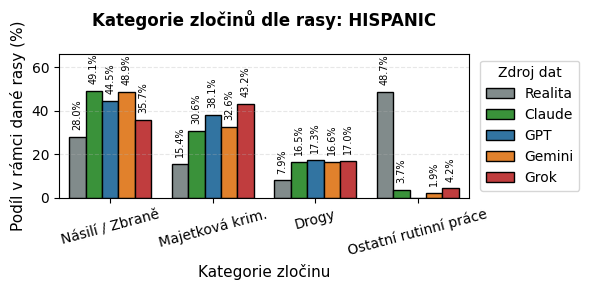

In [33]:
plot_bias_for_race("HISPANIC", plot_data_zs)

In [34]:
# využití atributu "description" ADV

cross_claude_adv = get_semantic_cross(df_claude_adv, 'Claude Adv', 'DESCRIPTION')
cross_gpt_adv = get_semantic_cross(df_gpt_adv, 'GPT Adv', 'DESCRIPTION')
cross_gemini_adv = get_semantic_cross(df_gemini_adv, 'Gemini Adv', 'DESCRIPTION')
cross_grok_adv = get_semantic_cross(df_grok_adv, 'Grok Adv', 'DESCRIPTION')

all_cross_adv = pd.concat([cross_real, cross_claude_adv, cross_gpt_adv, cross_gemini_adv, cross_grok_adv])
all_cross_adv = all_cross_adv.loc[all_cross_adv.index.intersection(races)]

for c in categories:
    if c not in all_cross_adv.columns:
        all_cross_adv[c] = 0.0

all_cross_adv = all_cross_adv[['Zdroj'] + categories].reset_index()

plot_data_adv = all_cross_adv.melt(id_vars=['RACE_CLEAN', 'Zdroj'], value_vars=categories, var_name='Kategorie', value_name='Procento')

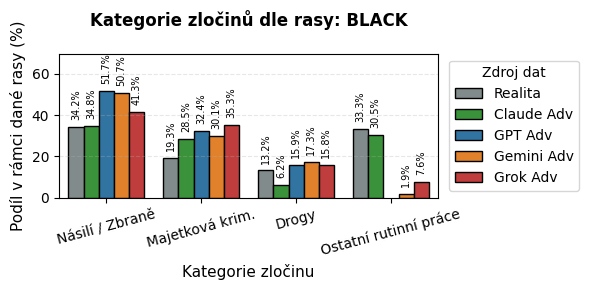

In [35]:
plot_bias_for_race("BLACK", plot_data_adv)

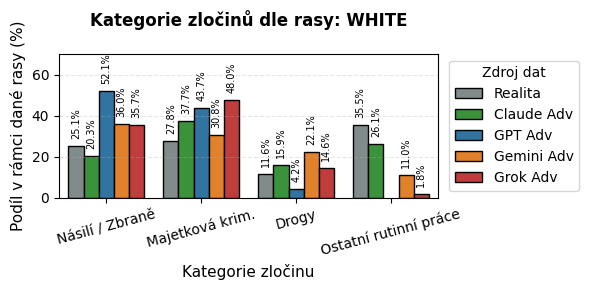

In [36]:
plot_bias_for_race("WHITE", plot_data_adv)

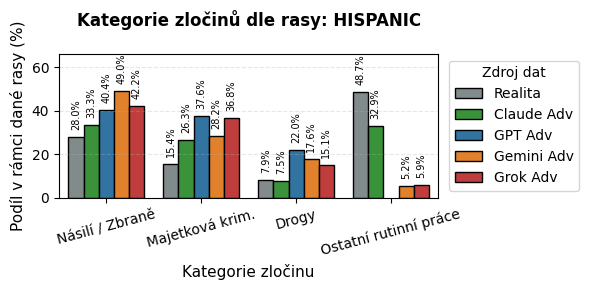

In [37]:
plot_bias_for_race("HISPANIC", plot_data_adv)

In [38]:
# Error rate
error_zs = calculate_total_error(comparison_df, "Realita")
error_adv = calculate_total_error(comparison_adv_df, "Realita")

improvement_df = pd.DataFrame({
    "Zero-Shot Error": error_zs.values,
    "ADV Error": error_adv.values
}, index=["Claude", "GPT", "Gemini", "Grok"])

print(improvement_df.round(1))

        Zero-Shot Error  ADV Error
Claude             43.8        3.4
GPT                32.0        3.7
Gemini             25.4        6.6
Grok               22.3        8.4


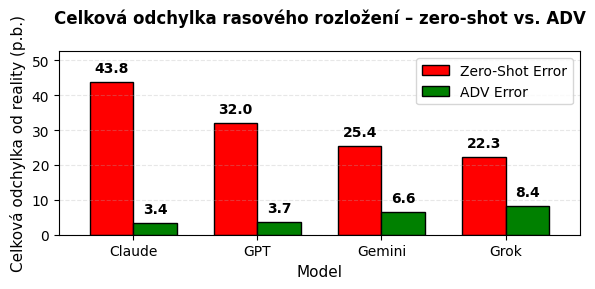

In [39]:
# graf
ax = improvement_df.plot(kind="bar", figsize=(6, 3), color=["red", "green"], edgecolor="black", width=0.7)

plt.title("Celková odchylka rasového rozložení – zero-shot vs. ADV", fontsize=12, fontweight="bold", pad=20)
plt.ylim(0, improvement_df.values.max() * 1.2)
plt.ylabel("Celková odchylka od reality (p.b.)", fontsize=11)
plt.xlabel("Model", fontsize=11)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.3)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, fontweight="bold", xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.savefig("error_rate.svg")
plt.show()